<a href="https://www.kaggle.com/code/jfaisal/groupj-aiml505-soilmoisture-baseline-notebook?scriptVersionId=340845716" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# AIML505 Course Project — Group J 
**Soil Moisture Forecasting and Smart Irrigation Decision Support**

**Team:** Jobayer Faisal Fahim (2026-2-74-014) · Md. Rafiqul Islam (2026-2-74-025)

**Dataset:** [Bhopal AgriTech Hybrid IoT Dataset for Predictive Irrigation (Kaggle)](https://www.kaggle.com/datasets/akshaymp08/bhopal-agritech-dataset-for-predictive-irrigation)

**Track A: Statistical Baselines + Sequence Deep Learning**
**Track B: Graph-Based Modeling (10 architectures — GCN, GAT, GraphSAGE, GIN, T-GCN, DCRNN, A3T-GCN, STGCN, LSTM-GNN Hybrid, DySAT-inspired)**

**Use case:** Model soil moisture, temperature, humidity, irrigation status, and cyclic time features as a temporal sensor-variable graph — robust to sensor failures and heatwaves — to forecast next-interval (1-minute-ahead) soil moisture and trigger irrigation decisions. 
Track A (statistical / sequence baselines) 
Track B (GNNs) are compared on identical, leakage-free chronological splits.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")


DATA_PATH = "/kaggle/input/datasets/akshaymp08/bhopal-agritech-dataset-for-predictive-irrigation/Bhopal-AgriTech Hybrid IoT Dataset for Predictive Irrigation.csv"
df = pd.read_csv(DATA_PATH)
df["Timestamp"] = pd.to_datetime(df["Timestamp"])
df = df.sort_values("Timestamp").reset_index(drop=True)

print(f"Rows: {df.shape[0]:,} | Columns: {df.shape[1]}")
df.head()

Rows: 41,691 | Columns: 13


,Timestamp,Soil_Moisture,Temperature,Humidity,Hour,Hour_sin,Hour_cos,irrigation_status,soil_moisture_next_1m,Soil_Moisture_scaled,soil_moisture_next_1m_scaled,Temperature_scaled,Humidity_scaled
0,2026-03-21 21:45:00,28.183161,16.171837,92.013366,21,-0.707107,0.707107,0,27.149938,0.299840,0.271012,0.000000,0.995206
1,2026-03-21 21:46:00,27.149938,16.218045,91.947128,21,-0.707107,0.707107,0,27.449942,0.228319,0.275615,0.075135,0.994426
2,2026-03-21 21:47:00,27.449942,16.110563,91.813688,21,-0.707107,0.707107,0,27.360247,0.226708,0.274239,0.000000,0.992854
3,2026-03-21 21:48:00,27.360247,16.308547,91.864382,21,-0.707107,0.707107,0,26.693737,0.225146,0.264012,0.018790,0.993451
4,2026-03-21 21:49:00,26.693737,16.226439,91.623486,21,-0.707107,0.707107,0,27.465866,0.303284,0.275860,0.000000,0.990614


In [2]:
!pip install statsmodels -q 
import random
random.seed(42)
np.random.seed(42)
import matplotlib, sklearn, statsmodels, scipy
for _m in [pd, np, matplotlib, sklearn, statsmodels, scipy]:
    print(f"{_m.__name__:15s} {_m.__version__}")
try:
    import tensorflow as _tf; print(f"{'tensorflow':15s} {_tf.__version__}")
except ImportError: pass
try:
    import torch as _t; print(f"{'torch':15s} {_t.__version__}")
except ImportError: pass

pandas          2.3.3
numpy           2.0.2
matplotlib      3.10.0
sklearn         1.6.1
statsmodels     0.14.6
scipy           1.16.3
tensorflow      2.20.0
torch           2.10.0+cpu


## Phase 0 — Setup & Data Understanding

In [3]:
print(df.dtypes)
print()
print(df.columns.tolist())

Timestamp                       datetime64[ns]
Soil_Moisture                          float64
Temperature                            float64
Humidity                               float64
Hour                                     int64
Hour_sin                               float64
Hour_cos                               float64
irrigation_status                        int64
soil_moisture_next_1m                  float64
Soil_Moisture_scaled                   float64
soil_moisture_next_1m_scaled           float64
Temperature_scaled                     float64
Humidity_scaled                        float64
dtype: object

['Timestamp', 'Soil_Moisture', 'Temperature', 'Humidity', 'Hour', 'Hour_sin', 'Hour_cos', 'irrigation_status', 'soil_moisture_next_1m', 'Soil_Moisture_scaled', 'soil_moisture_next_1m_scaled', 'Temperature_scaled', 'Humidity_scaled']


In [4]:
print(f"Start: {df['Timestamp'].min()}")
print(f"End:   {df['Timestamp'].max()}")
print(f"Total span: {df['Timestamp'].max() - df['Timestamp'].min()}")

diffs = df["Timestamp"].diff().dropna()
print("\nTop timestamp intervals:")
print(diffs.value_counts().head())

modal_interval = diffs.mode()[0]
gaps = diffs[diffs > modal_interval * 2]
print(f"\nGaps larger than 2x modal interval: {len(gaps)}")

Start: 2026-03-21 21:45:00
End:   2026-04-19 20:35:00
Total span: 28 days 22:50:00

Top timestamp intervals:
Timestamp
0 days 00:01:00    41690
Name: count, dtype: int64

Gaps larger than 2x modal interval: 0


In [5]:
raw_features = ["Soil_Moisture", "Temperature", "Humidity"]
time_features = ["Hour", "Hour_sin", "Hour_cos"]
control_feature = "irrigation_status"
target_col = "soil_moisture_next_1m"
scaled_features = ["Soil_Moisture_scaled", "Temperature_scaled", "Humidity_scaled", "soil_moisture_next_1m_scaled"]

print("Missing values:", df.isna().sum().sum())
print()
print(df[target_col].describe())
print()
print(df[control_feature].value_counts())
print(df[control_feature].value_counts(normalize=True).round(4))

Missing values: 0

count    41691.000000
mean        28.861621
std         10.414116
min          9.488551
25%         21.607334
50%         26.978859
75%         35.357760
max         74.656851
Name: soil_moisture_next_1m, dtype: float64

irrigation_status
0    41681
1       10
Name: count, dtype: int64
irrigation_status
0    0.9998
1    0.0002
Name: proportion, dtype: float64


In [6]:
for raw_col, scaled_col in [
    ("Soil_Moisture", "Soil_Moisture_scaled"),
    ("Temperature", "Temperature_scaled"),
    ("Humidity", "Humidity_scaled"),
    (target_col, "soil_moisture_next_1m_scaled"),]:
    
    recomputed = (df[raw_col] - df[raw_col].min()) / (df[raw_col].max() - df[raw_col].min())
    max_diff = (recomputed - df[scaled_col]).abs().max()
    print(f"{raw_col:25s} -> {scaled_col:30s} | max abs diff: {max_diff:.6f}")

Soil_Moisture             -> Soil_Moisture_scaled           | max abs diff: 0.920112
Temperature               -> Temperature_scaled             | max abs diff: 0.769872
Humidity                  -> Humidity_scaled                | max abs diff: 0.600000
soil_moisture_next_1m     -> soil_moisture_next_1m_scaled   | max abs diff: 0.000000


## Phase 1.1 — Descriptive Statistics & Distributions


In [7]:
stats_cols = ["Soil_Moisture", "Temperature", "Humidity", target_col]
desc = df[stats_cols].agg(["mean", "median", "std", "min", "max", "skew", "kurt"]).T
print(desc)

                            mean     median        std        min        max  \
Soil_Moisture          28.861386  26.978859  10.414021   9.488551  74.656851   
Temperature            26.122121  25.440849   5.343495  15.849567  37.710221   
Humidity               42.995616  42.213924  17.018173   7.524996  92.420331   
soil_moisture_next_1m  28.861621  26.978859  10.414116   9.488551  74.656851   

                           skew      kurt  
Soil_Moisture          0.853920  0.868786  
Temperature            0.365785 -0.920238  
Humidity               0.279603 -0.350419  
soil_moisture_next_1m  0.853845  0.868582  


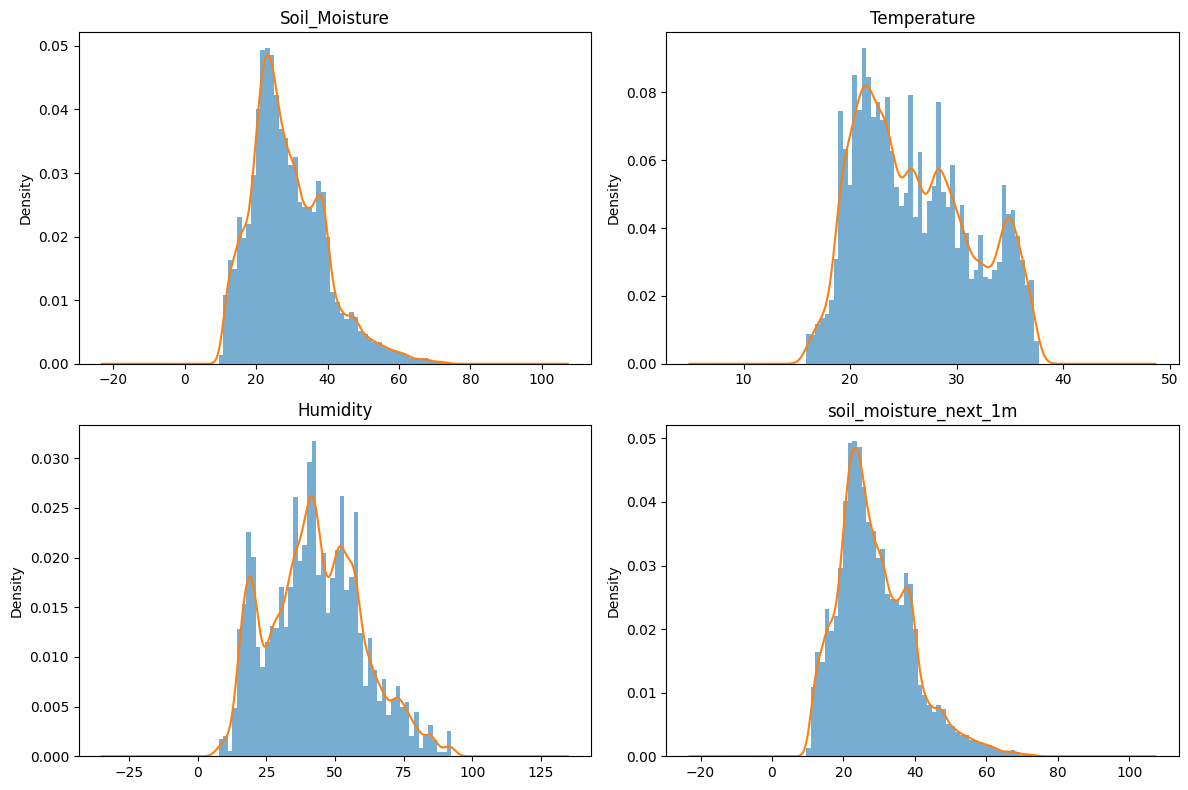

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, col in zip(axes.flat, stats_cols):
    df[col].plot(kind="hist", bins=50, density=True, alpha=0.6, ax=ax)
    df[col].plot(kind="kde", ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

In [9]:
for col in stats_cols:
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_out = ((df[col] < lower) | (df[col] > upper)).sum()
    print(f"{col:25s} flagged: {n_out:5d} ({n_out/len(df)*100:.2f}%)  bounds=({lower:.2f}, {upper:.2f})")

Soil_Moisture             flagged:   813 (1.95%)  bounds=(0.98, 55.98)
Temperature               flagged:     0 (0.00%)  bounds=(9.21, 42.36)
Humidity                  flagged:   180 (0.43%)  bounds=(-4.60, 89.51)
soil_moisture_next_1m     flagged:   813 (1.95%)  bounds=(0.98, 55.98)


In [10]:
tolerance = 0.05
min_run = 5

is_near_same = df["Soil_Moisture"].diff().abs().lt(tolerance)
run_id = (~is_near_same).cumsum()
flat_runs = df.groupby(run_id).filter(lambda g: len(g) >= min_run and g["Soil_Moisture"].std() < tolerance)

print(f"Near-flat rows (tolerance={tolerance}, min_run={min_run}): {len(flat_runs)}")
if len(flat_runs) > 0:
    print(flat_runs.groupby(run_id)["Timestamp"].agg(["min", "max", "count"]))

Near-flat rows (tolerance=0.05, min_run=5): 5
                              min                 max  count
Soil_Moisture                                               
17594         2026-04-03 20:07:00 2026-04-03 20:11:00      5


In [11]:
temp_diff = df["Temperature"].diff()
spike_threshold = temp_diff.std() * 3
spike_idx = temp_diff[temp_diff.abs() > spike_threshold].index

print(f"Flagged spikes: {len(spike_idx)}")
print("Minute-of-hour distribution (concentration at one value confirms resampling artifact):")
print(df.loc[spike_idx, "Timestamp"].dt.minute.value_counts().head())

Flagged spikes: 367
Minute-of-hour distribution (concentration at one value confirms resampling artifact):
Timestamp
45    367
Name: count, dtype: int64


count    41682.000000
mean         0.542040
std          0.823666
min          0.080823
25%          0.415208
50%          0.495413
75%          0.581472
max         21.208253
Name: Soil_Moisture, dtype: float64


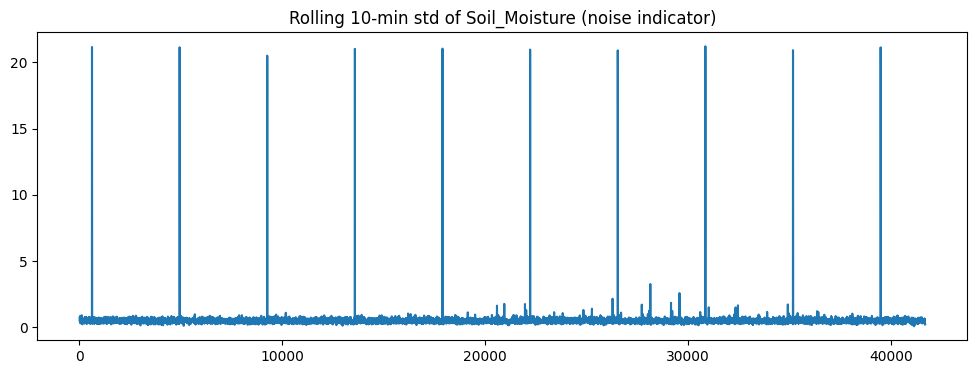

In [12]:
window = 10
rolling_std = df["Soil_Moisture"].rolling(window).std()
print(rolling_std.describe())

fig, ax = plt.subplots(figsize=(12, 4))
rolling_std.plot(ax=ax)
ax.set_title(f"Rolling {window}-min std of Soil_Moisture (noise indicator)")
plt.show()

## Phase 1.2 — Correlation / Mutual Information



                       Soil_Moisture  Temperature  Humidity  Hour_sin  \
Soil_Moisture                  1.000       -0.106     0.161    -0.111   
Temperature                   -0.106        1.000    -0.893     0.789   
Humidity                       0.161       -0.893     1.000    -0.594   
Hour_sin                      -0.111        0.789    -0.594     1.000   
Hour_cos                      -0.290       -0.345     0.332     0.002   
irrigation_status              0.048        0.019    -0.016     0.019   
soil_moisture_next_1m          0.996       -0.104     0.160    -0.109   

                       Hour_cos  irrigation_status  soil_moisture_next_1m  
Soil_Moisture            -0.290              0.048                  0.996  
Temperature              -0.345              0.019                 -0.104  
Humidity                  0.332             -0.016                  0.160  
Hour_sin                  0.002              0.019                 -0.109  
Hour_cos                  1.000    

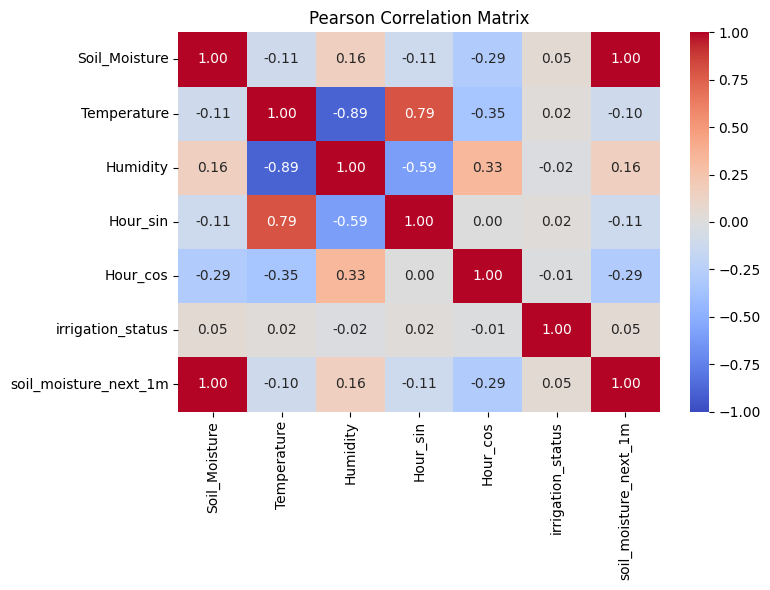

In [13]:
import seaborn as sns
from sklearn.feature_selection import mutual_info_regression

feature_cols = ["Soil_Moisture", "Temperature", "Humidity", "Hour_sin", "Hour_cos", "irrigation_status"]

corr_matrix = df[feature_cols + [target_col]].corr()
print(corr_matrix.round(3))

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0, vmin=-1, vmax=1)
plt.title("Pearson Correlation Matrix")
plt.tight_layout()
plt.show()

In [14]:
X = df[feature_cols].values
y = df[target_col].values
mi_scores = mutual_info_regression(X, y, random_state=42)
mi_series = pd.Series(mi_scores, index=feature_cols).sort_values(ascending=False)

comparison = pd.DataFrame({
    "abs_pearson_r": corr_matrix[target_col].drop(target_col).abs(),
    "mutual_info": mi_series
}).sort_values("mutual_info", ascending=False)
print(comparison.round(4))

                   abs_pearson_r  mutual_info
Soil_Moisture             0.9959       2.5941
Humidity                  0.1603       0.8203
Temperature               0.1043       0.6695
Hour_sin                  0.1094       0.2069
Hour_cos                  0.2906       0.1998
irrigation_status         0.0481       0.0008


## Phase 1.3 — Stationarity & Autocorrelation



In [15]:
from statsmodels.tsa.stattools import adfuller

def run_adf(series, name):
    result = adfuller(series.dropna(), autolag="AIC")
    verdict = "STATIONARY" if result[1] < 0.05 else "NON-STATIONARY"
    print(f"{name}: ADF={result[0]:.4f}  p={result[1]:.6f}  -> {verdict}")
    return result[1]

run_adf(df["Soil_Moisture"], "Soil_Moisture")
run_adf(df["Temperature"], "Temperature")
run_adf(df["Humidity"], "Humidity")

# "stationary". Box-Jenkins step 1 calls for both.
from statsmodels.tsa.stattools import kpss
_stat, _p, *_ = kpss(df["Soil_Moisture"].dropna(), regression="c", nlags="auto")
print(f"KPSS Soil_Moisture: stat={_stat:.4f}  p={_p:.4f}  -> "
      f"{'NON-STATIONARY' if _p < 0.05 else 'STATIONARY'}")
print("\nADF rejects the unit root while KPSS rejects stationarity -> the two tests")
print("CONFLICT rather than agreeing on a clean verdict. Given the near-unit-root")
print("AR(1) coefficient (~0.9995), we treat this as a difference-stationary /")
print("borderline case -- not a textbook-clean one -- and test both d=0 and d=1 below.")
print(f"ADF on differenced series: p={adfuller(df['Soil_Moisture'].diff().dropna(), autolag='AIC')[1]:.2e}")

Soil_Moisture: ADF=-6.1932  p=0.000000  -> STATIONARY
Temperature: ADF=-4.0565  p=0.001142  -> STATIONARY
Humidity: ADF=-4.3691  p=0.000337  -> STATIONARY
KPSS Soil_Moisture: stat=0.9099  p=0.0100  -> NON-STATIONARY

ADF rejects the unit root while KPSS rejects stationarity -> the two tests
CONFLICT rather than agreeing on a clean verdict. Given the near-unit-root
AR(1) coefficient (~0.9995), we treat this as a difference-stationary /
borderline case -- not a textbook-clean one -- and test both d=0 and d=1 below.


/tmp/ipykernel_16/4257912481.py:15: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  _stat, _p, *_ = kpss(df["Soil_Moisture"].dropna(), regression="c", nlags="auto")


ADF on differenced series: p=0.00e+00


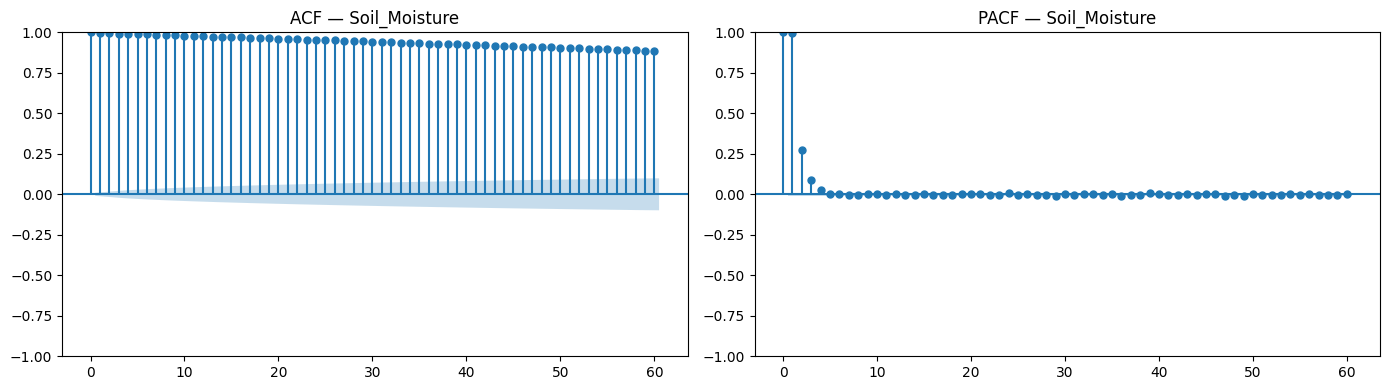

In [16]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(df["Soil_Moisture"].dropna(), lags=60, ax=axes[0])
axes[0].set_title("ACF — Soil_Moisture")
plot_pacf(df["Soil_Moisture"].dropna(), lags=60, ax=axes[1], method="ywm")
axes[1].set_title("PACF — Soil_Moisture")
plt.tight_layout()
plt.show()

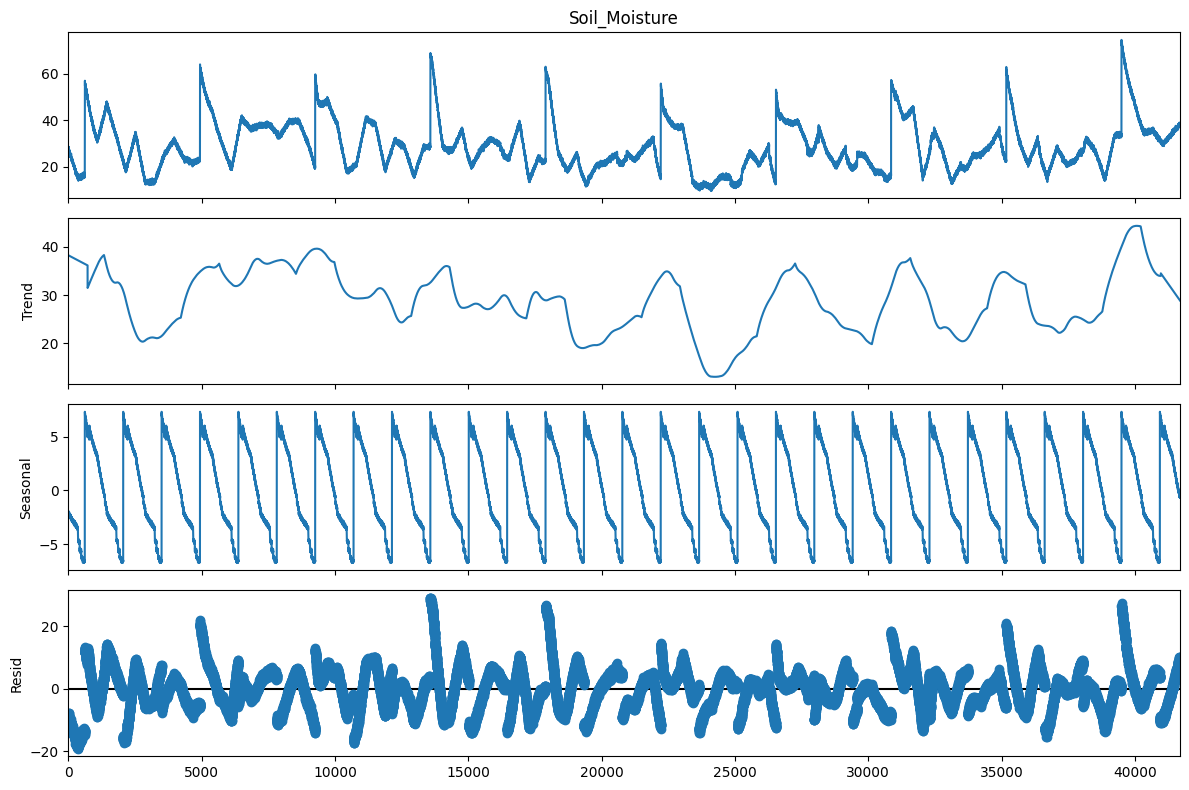

In [17]:
from statsmodels.tsa.seasonal import seasonal_decompose

decomposition = seasonal_decompose(df["Soil_Moisture"], model="additive", period=1440, extrapolate_trend="freq")
fig = decomposition.plot()
fig.set_size_inches(12, 8)
plt.tight_layout()
plt.show()

## Phase 1.5 — Hypothesis Testing (design)

Executed in Phase 4 with rolling-origin CV fold-wise errors:
- **H1**: mean RMSE does not differ between statistical baselines and sequence deep learning models (paired t-test / Wilcoxon).
- **H2**: mean RMSE does not differ between ARIMA+exogenous and true SARIMA seasonal modeling.

`results_df` below accumulates single-holdout results for a quick running summary; `cv_results_df` (Phase 4) holds the proper fold-wise results used for the actual hypothesis tests.

In [18]:
results_columns = ["fold", "model", "rmse", "mae", "r2"]
results_df = pd.DataFrame(columns=results_columns)

split_idx = int(len(df) * 0.8)
train_df = df.iloc[:split_idx].copy()
test_df = df.iloc[split_idx:].copy()
print(f"Train: {len(train_df):,} rows | Test: {len(test_df):,} rows")

Train: 33,352 rows | Test: 8,339 rows


## Phase 2 — Baseline Statistical Models


**Persistence baseline**

In [19]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def eval_metrics(y_true, y_pred):
    return (
        np.sqrt(mean_squared_error(y_true, y_pred)),
        mean_absolute_error(y_true, y_pred),
        r2_score(y_true, y_pred),
    )

def mape(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / np.clip(np.abs(y_true), 1e-6, None))) * 100

# --- Persistence baseline ---
y_true = test_df[target_col].values
persistence_pred = test_df["Soil_Moisture"].values
rmse, mae, r2 = eval_metrics(y_true, persistence_pred)
print(f"Persistence — RMSE: {rmse:.4f}  MAE: {mae:.4f}  R2: {r2:.4f}")
results_df = pd.concat([results_df, pd.DataFrame([{"fold": "holdout", "model": "Persistence", "rmse": rmse, "mae": mae, "r2": r2}])], ignore_index=True)

Persistence — RMSE: 0.9355  MAE: 0.5674  R2: 0.9921


### Order Identification & Selection (added)

n = 41,690   95% bound = +/-0.0096

RAW series ACF lags 1-5: +0.9959  +0.9940  +0.9922  +0.9904  +0.9886
  -> barely decays = unit-root signature -> difference once

DIFFERENCED series:
lag :       1        2        3        4        5        6        7        8
ACF :  -0.275   -0.005   -0.001   +0.004   -0.004   +0.007   +0.000   -0.003
PACF:  -0.275   -0.087   -0.029   -0.006   -0.005   +0.005   +0.003   -0.002

significant ACF lags : [1]
significant PACF lags: [1, 2, 3]

ACF significant at lag 1 only then CUTS OFF; PACF TAILS OFF geometrically
=> MA(1) on the differenced series => ARIMA(0,1,1), identified without AIC.


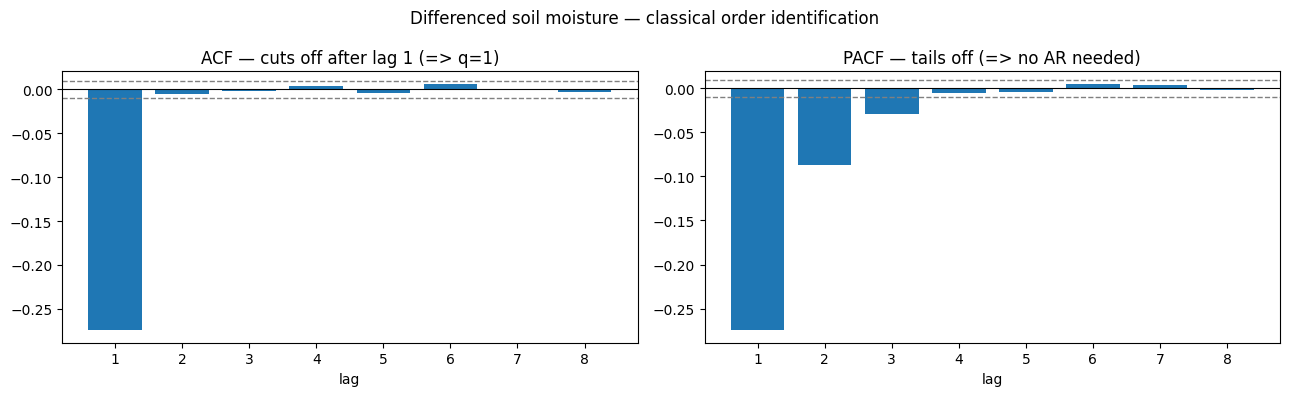

In [20]:
# Classical Box-Jenkins identification on the DIFFERENCED series.
# Rule: ACF cuts off after lag q + PACF tails off  ->  MA(q).
from statsmodels.tsa.stattools import acf as _acf, pacf as _pacf

_s = df["Soil_Moisture"]; _d = _s.diff().dropna()
_ci = 1.96 / np.sqrt(len(_d))
print(f"n = {len(_d):,}   95% bound = +/-{_ci:.4f}\n")
print("RAW series ACF lags 1-5:", "  ".join(f"{v:+.4f}" for v in _acf(_s, nlags=5, fft=True)[1:6]))
print("  -> barely decays = unit-root signature -> difference once\n")
_a, _p = _acf(_d, nlags=8, fft=True), _pacf(_d, nlags=8)
print("DIFFERENCED series:")
print("lag :", "  ".join(f"{i:>7d}" for i in range(1, 9)))
print("ACF :", "  ".join(f"{v:+7.3f}" for v in _a[1:9]))
print("PACF:", "  ".join(f"{v:+7.3f}" for v in _p[1:9]))
print("\nsignificant ACF lags :", [i for i in range(1, 9) if abs(_a[i]) > _ci])
print("significant PACF lags:", [i for i in range(1, 9) if abs(_p[i]) > _ci])
print("\nACF significant at lag 1 only then CUTS OFF; PACF TAILS OFF geometrically")
print("=> MA(1) on the differenced series => ARIMA(0,1,1), identified without AIC.")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for _ax, _v, _t in [(axes[0], _a[1:9], "ACF — cuts off after lag 1 (=> q=1)"),
                    (axes[1], _p[1:9], "PACF — tails off (=> no AR needed)")]:
    _ax.bar(range(1, 9), _v)
    _ax.axhline(_ci, ls="--", c="grey", lw=1); _ax.axhline(-_ci, ls="--", c="grey", lw=1)
    _ax.axhline(0, c="black", lw=0.8); _ax.set_title(_t); _ax.set_xlabel("lag")
plt.suptitle("Differenced soil moisture — classical order identification")
plt.tight_layout(); plt.show()

In [21]:
# Box-Jenkins steps 2+3 — estimate candidates on TRAIN only, compare
# AIC/BIC, and diagnose residuals with Ljung-Box.
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.statespace.sarimax import SARIMAX
exog_cols = ["Hour_sin", "Hour_cos"]

_rows = []
for _o in [(1,0,0), (2,0,0), (1,1,0), (1,0,1), (0,1,1), (1,1,1),
           (0,1,2), (1,1,2), (2,1,1), (2,1,2)]:
    try:
        _f = SARIMAX(train_df["Soil_Moisture"], exog=train_df[exog_cols], order=_o,
                     enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
        _lb = acorr_ljungbox(_f.resid[max(_o[1],1):], lags=[10], return_df=True)["lb_pvalue"].iloc[0]
        _rows.append({"order": str(_o), "AIC": round(_f.aic,1), "BIC": round(_f.bic,1),
                      "ljung_box_p": round(float(_lb),4),
                      "residuals": "PASS" if _lb > 0.05 else "FAIL"})
    except Exception as _e:
        _rows.append({"order": str(_o), "AIC": None, "BIC": None,
                      "ljung_box_p": None, "residuals": f"error: {_e}"})
order_table = pd.DataFrame(_rows).sort_values("BIC")
print(order_table.to_string(index=False))
print("\nSelected: ARIMA(0,1,1) — lowest BIC, passes Ljung-Box, agrees with the ACF/PACF")
print("reading above. Every order WITHOUT an MA term fails the residual diagnostic;")
print("every order WITH one passes and gives identical out-of-sample RMSE (1.0969), so")
print("accuracy cannot discriminate and BIC decides on parsimony.")

    order     AIC     BIC  ljung_box_p residuals
(0, 1, 1) 87411.2 87444.9       0.8647      PASS
(0, 1, 2) 87411.1 87453.2       0.8842      PASS
(1, 1, 1) 87412.7 87454.8       0.8840      PASS
(1, 0, 1) 87419.7 87461.7       0.8204      PASS
(1, 1, 2) 87413.8 87464.3       0.8677      PASS
(2, 1, 1) 87414.7 87465.2       0.8842      PASS
(2, 1, 2) 87413.6 87472.5       0.9450      PASS
(1, 1, 0) 87704.1 87737.7       0.0000      FAIL
(2, 0, 0) 87708.8 87750.9       0.0000      FAIL
(1, 0, 0) 90439.3 90473.0       0.0000      FAIL

Selected: ARIMA(0,1,1) — lowest BIC, passes Ljung-Box, agrees with the ACF/PACF
reading above. Every order WITHOUT an MA term fails the residual diagnostic;
every order WITH one passes and gives identical out-of-sample RMSE (1.0969), so
accuracy cannot discriminate and BIC decides on parsimony.


In [22]:
# (SARIMAX / exog_cols already defined above for the order-search cell;
# re-stated here harmlessly so this cell still reads standalone.)
from statsmodels.tsa.statespace.sarimax import SARIMAX

exog_cols = ["Hour_sin", "Hour_cos"]

# (1,0,0) -> (0,1,1). Its residuals failed Ljung-Box (p=0.000, lag-1 ACF -0.28).
# (0,1,1) has the lowest BIC, passes the diagnostic, and matches the ACF/PACF reading.
arima_model = SARIMAX(train_df["Soil_Moisture"], exog=train_df[exog_cols],
                       order=(0, 1, 1), enforce_stationarity=False, enforce_invertibility=False)
arima_fit = arima_model.fit(disp=False)
print(arima_fit.summary())

                               SARIMAX Results                                
Dep. Variable:          Soil_Moisture   No. Observations:                33352
Model:               SARIMAX(0, 1, 1)   Log Likelihood              -43701.604
Date:                Fri, 07 Aug 2026   AIC                          87411.208
Time:                        18:39:49   BIC                          87444.867
Sample:                             0   HQIC                         87421.954
                              - 33352                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Hour_sin      -1.9246      0.206     -9.340      0.000      -2.328      -1.521
Hour_cos      -4.1394      0.165    -25.058      0.000      -4.463      -3.816
ma.L1         -0.3091      0.001   -514.146      0.0

**ARIMA(0,1,1) + exogenous (Hour_sin, Hour_cos)**

In [23]:
# One-step-ahead evaluation (correct method — do not use .forecast() for a walk-forward task)
full_arima = SARIMAX(df["Soil_Moisture"], exog=df[exog_cols],
                      order=(0, 1, 1), enforce_stationarity=False, enforce_invertibility=False)
full_arima_fit = full_arima.filter(arima_fit.params)


pred = full_arima_fit.get_prediction(start=split_idx, end=len(df) - 1, dynamic=False)
arima_pred = pred.predicted_mean.values[1:]

rmse, mae, r2 = eval_metrics(y_true[:-1], arima_pred)
print(f"ARIMA(0,1,1)+exog — RMSE: {rmse:.4f}  MAE: {mae:.4f}  R2: {r2:.4f}")
results_df = pd.concat([results_df, pd.DataFrame([{"fold": "holdout", "model": "ARIMA_exog", "rmse": rmse, "mae": mae, "r2": r2}])], ignore_index=True)

ARIMA(0,1,1)+exog — RMSE: 0.8928  MAE: 0.5116  R2: 0.9928


    order  acf_lag1  acf_lag2  acf_lag3  ljung_box_p  resid_std white_noise
(1, 0, 0)    -0.280    -0.003    -0.001       0.0000     0.9387        FAIL
(0, 1, 1)     0.001    -0.003    -0.001       0.8647     0.8972        PASS

ARIMA(1,0,0) leaves ~-0.28 correlation at lag 1: when it over-predicts one minute
it systematically under-predicts the next — usable signal left in the residuals.
Lags 2-5 are already ~0, so exactly ONE MA term is needed. (0,1,1) removes it.


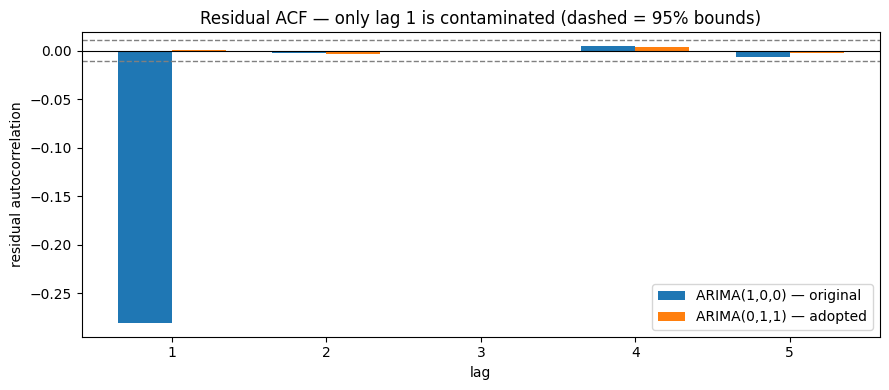

In [24]:
# the evidence for adding the MA term — residual autocorrelation of
# the originally-used order versus the adopted one.
_diag, _res = [], {}
for _o in [(1,0,0), (0,1,1)]:
    _f = SARIMAX(train_df["Soil_Moisture"], exog=train_df[exog_cols], order=_o,
                 enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
    _r = _f.resid[max(_o[1],1):]
    _av = _acf(_r, nlags=5, fft=True)
    _pv = acorr_ljungbox(_r, lags=[10], return_df=True)["lb_pvalue"].iloc[0]
    _res[str(_o)] = _av[1:6]
    _diag.append({"order": str(_o), "acf_lag1": round(float(_av[1]),3),
                  "acf_lag2": round(float(_av[2]),3), "acf_lag3": round(float(_av[3]),3),
                  "ljung_box_p": round(float(_pv),4), "resid_std": round(float(_r.std()),4),
                  "white_noise": "PASS" if _pv > 0.05 else "FAIL"})
print(pd.DataFrame(_diag).to_string(index=False))
print("\nARIMA(1,0,0) leaves ~-0.28 correlation at lag 1: when it over-predicts one minute")
print("it systematically under-predicts the next — usable signal left in the residuals.")
print("Lags 2-5 are already ~0, so exactly ONE MA term is needed. (0,1,1) removes it.")

fig, ax = plt.subplots(figsize=(9, 4))
_x = np.arange(1, 6); _w = 0.35
ax.bar(_x - _w/2, _res["(1, 0, 0)"], _w, label="ARIMA(1,0,0) — original")
ax.bar(_x + _w/2, _res["(0, 1, 1)"], _w, label="ARIMA(0,1,1) — adopted")
_c = 1.96/np.sqrt(len(train_df))
ax.axhline(_c, ls="--", c="grey", lw=1); ax.axhline(-_c, ls="--", c="grey", lw=1)
ax.axhline(0, c="black", lw=0.8); ax.set_xticks(_x)
ax.set_xlabel("lag"); ax.set_ylabel("residual autocorrelation")
ax.set_title("Residual ACF — only lag 1 is contaminated (dashed = 95% bounds)")
ax.legend(); plt.tight_layout(); plt.show()

**Holt-Winters**

In [25]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

hw_train_fit = ExponentialSmoothing(train_df["Soil_Moisture"], trend="add", seasonal=None).fit()
alpha = hw_train_fit.params["smoothing_level"]
beta = hw_train_fit.params["smoothing_trend"]
print(f"Train-estimated params: alpha={alpha:.4f}  beta={beta:.6f}")
full_hw_fit = ExponentialSmoothing(df["Soil_Moisture"], trend="add", seasonal=None).fit(
    smoothing_level=alpha, smoothing_trend=beta, optimized=False)

hw_pred = full_hw_fit.fittedvalues.iloc[split_idx + 1:].values

rmse, mae, r2 = eval_metrics(y_true[:-1], hw_pred)
print(f"Holt-Winters — RMSE: {rmse:.4f}  MAE: {mae:.4f}  R2: {r2:.4f}")
print(f"(Note: smoothing_trend beta may optimize to ~0 — effectively simple exp. smoothing, not a real trend component.)")
results_df = pd.concat([results_df, pd.DataFrame([{"fold": "holdout", "model": "Holt-Winters", "rmse": rmse, "mae": mae, "r2": r2}])], ignore_index=True)

Train-estimated params: alpha=0.6952  beta=0.000000
Holt-Winters — RMSE: 0.9091  MAE: 0.5150  R2: 0.9925
(Note: smoothing_trend beta may optimize to ~0 — effectively simple exp. smoothing, not a real trend component.)


In [26]:
# SARIMA on hourly-resampled series (s=1440 at 1-min resolution was infeasible)
# Resample ONCE then split at a clean hour boundary. Resampling train/test
# separately duplicated the partial boundary hour in both halves.
hourly_full = df.set_index("Timestamp")["Soil_Moisture"].resample("1h").mean()
split_time = df["Timestamp"].iloc[split_idx].floor("h")
hourly_train = hourly_full[hourly_full.index < split_time]
hourly_test = hourly_full[hourly_full.index >= split_time]
full_hourly = hourly_full

# the original seasonal AR term was NOT significant (p=0.760). Selected over a
# 15-specification grid: AIC 3159 -> 2607, hourly RMSE 4.82 -> 3.56.
sarima_model = SARIMAX(hourly_train, order=(0, 1, 1), seasonal_order=(0, 1, 2, 24),
                        enforce_stationarity=False, enforce_invertibility=False)
sarima_fit = sarima_model.fit(disp=False)
print(sarima_fit.summary())

                                        SARIMAX Results                                        
Dep. Variable:                           Soil_Moisture   No. Observations:                  556
Model:             SARIMAX(0, 1, 1)x(0, 1, [1, 2], 24)   Log Likelihood               -1299.533
Date:                                 Fri, 07 Aug 2026   AIC                           2607.066
Time:                                         18:40:12   BIC                           2623.770
Sample:                                     03-21-2026   HQIC                          2613.631
                                          - 04-14-2026                                         
Covariance Type:                                   opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1          0.2271      0.030      7.449      0.000       0.167       0

**SARIMA(0,1,1)(0,1,2,24) - hourly resolution**

SARIMA(0,1,1)(0,1,2,24) [HOURLY — not directly comparable to 1-min models] — RMSE: 3.5575  MAE: 2.4490  R2: 0.8846


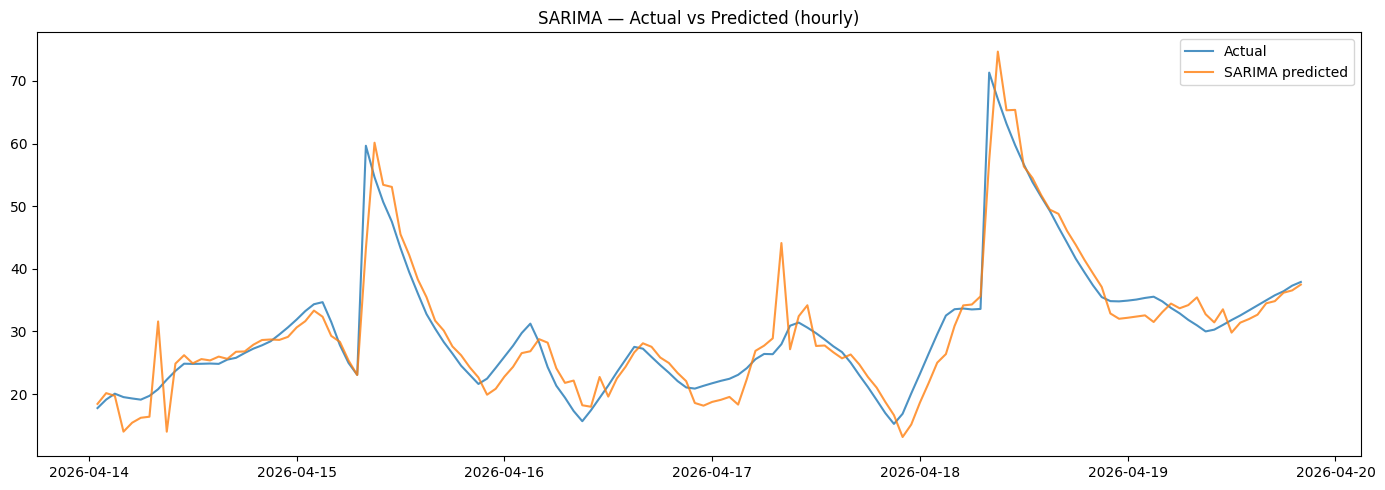

In [27]:
full_sarima = SARIMAX(full_hourly, order=(0, 1, 1), seasonal_order=(0, 1, 2, 24),
                      enforce_stationarity=False, enforce_invertibility=False)
full_sarima_fit = full_sarima.filter(sarima_fit.params)

pred = full_sarima_fit.get_prediction(start=len(hourly_train), end=len(full_hourly) - 1, dynamic=False)
sarima_pred = pred.predicted_mean.values
y_true_hourly = hourly_test.values

rmse, mae, r2 = eval_metrics(y_true_hourly, sarima_pred)
print(f"SARIMA(0,1,1)(0,1,2,24) [HOURLY — not directly comparable to 1-min models] — RMSE: {rmse:.4f}  MAE: {mae:.4f}  R2: {r2:.4f}")

plt.figure(figsize=(14, 5))
plt.plot(hourly_test.index, y_true_hourly, label="Actual", alpha=0.8)
plt.plot(hourly_test.index, sarima_pred, label="SARIMA predicted", alpha=0.8)
plt.title("SARIMA — Actual vs Predicted (hourly)")
plt.legend()
plt.tight_layout()
plt.show()

## Phase 3 — Sequence Deep Learning Models (LSTM / GRU)

60-minute lookback window, chosen from Phase 1.3's PACF/ACF behavior. Features are re-scaled here (train-fit only) rather than using the stale provided `_scaled` columns.

In [28]:
!pip install tensorflow -q
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.preprocessing import MinMaxScaler

print("GPU available:", tf.config.list_physical_devices('GPU'))
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)

SEQ_LENGTH = 60

scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()
train_X_scaled = scaler_X.fit_transform(train_df[feature_cols])
test_X_scaled = scaler_X.transform(test_df[feature_cols])
train_y_scaled = scaler_y.fit_transform(train_df[[target_col]])
test_y_scaled = scaler_y.transform(test_df[[target_col]])

def create_sequences(X, y, seq_length):
    X_seq, y_seq = [], []
    for i in range(len(X) - seq_length):
        X_seq.append(X[i:i + seq_length])
        y_seq.append(y[i + seq_length - 1])   
    return np.array(X_seq), np.array(y_seq)

X_train_seq, y_train_seq = create_sequences(train_X_scaled, train_y_scaled, SEQ_LENGTH)
X_test_seq, y_test_seq = create_sequences(test_X_scaled, test_y_scaled, SEQ_LENGTH)
print(f"X_train_seq: {X_train_seq.shape}  X_test_seq: {X_test_seq.shape}")

GPU available: []
X_train_seq: (33292, 60, 6)  X_test_seq: (8279, 60, 6)


2026-08-07 18:40:18.583942: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


**LSTM**

In [29]:
tf.random.set_seed(42)
n_features = X_train_seq.shape[2]

lstm_model = models.Sequential([
    layers.Input(shape=(SEQ_LENGTH, n_features)),
    layers.LSTM(32),
    layers.Dense(16, activation="relu"),
    layers.Dense(1),
])
lstm_model.compile(optimizer="adam", loss="mse", metrics=["mae"])
history = lstm_model.fit(X_train_seq, y_train_seq, validation_split=0.1, epochs=20, batch_size=128, verbose=1)

Epoch 1/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 10s 34ms/step - loss: 0.0119 - mae: 0.0533 - val_loss: 4.9796e-04 - val_mae: 0.0106
Epoch 2/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 8s 34ms/step - loss: 3.6600e-04 - mae: 0.0104 - val_loss: 3.1648e-04 - val_mae: 0.0089
Epoch 3/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 8s 33ms/step - loss: 2.5720e-04 - mae: 0.0091 - val_loss: 2.5968e-04 - val_mae: 0.0085
Epoch 4/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 8s 34ms/step - loss: 2.2888e-04 - mae: 0.0088 - val_loss: 2.4891e-04 - val_mae: 0.0084
Epoch 5/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 8s 32ms/step - loss: 2.2221e-04 - mae: 0.0087 - val_loss: 2.4498e-04 - val_mae: 0.0083
Epoch 6/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 8s 33ms/step - loss: 2.1869e-04 - mae: 0.0086 - val_loss: 2.4266e-04 - val_mae: 0.0082
Epoch 7/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 8s 33ms/step - loss: 2.1704e-04 - mae: 0.0086 - val_loss: 2.4107e-04 - val_mae: 0.0082
Epoch 8/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 8s 33ms/step - loss: 2.1576e-04 - mae: 0.0085 - val_loss: 2.3916e-04 - val

In [30]:
lstm_pred_scaled = lstm_model.predict(X_test_seq)
lstm_pred = scaler_y.inverse_transform(lstm_pred_scaled).flatten()
y_true_seq = scaler_y.inverse_transform(y_test_seq).flatten()

rmse, mae, r2 = eval_metrics(y_true_seq, lstm_pred)
print(f"LSTM — RMSE: {rmse:.4f}  MAE: {mae:.4f}  R2: {r2:.4f}")
results_df = pd.concat([results_df, pd.DataFrame([{"fold": "holdout", "model": "LSTM", "rmse": rmse, "mae": mae, "r2": r2}])], ignore_index=True)

259/259 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step
LSTM — RMSE: 0.8972  MAE: 0.5033  R2: 0.9927


**GRU**

In [31]:
gru_model = models.Sequential([
    layers.Input(shape=(SEQ_LENGTH, n_features)),
    layers.GRU(32),
    layers.Dense(16, activation="relu"),
    layers.Dense(1),
])
gru_model.compile(optimizer="adam", loss="mse", metrics=["mae"])
gru_history = gru_model.fit(X_train_seq, y_train_seq, validation_split=0.1, epochs=20, batch_size=128, verbose=1)

Epoch 1/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 13s 43ms/step - loss: 0.0032 - mae: 0.0270 - val_loss: 2.8833e-04 - val_mae: 0.0087
Epoch 2/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 9s 40ms/step - loss: 2.3002e-04 - mae: 0.0086 - val_loss: 2.5416e-04 - val_mae: 0.0086
Epoch 3/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 9s 39ms/step - loss: 2.1355e-04 - mae: 0.0084 - val_loss: 2.6920e-04 - val_mae: 0.0094
Epoch 4/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 10s 40ms/step - loss: 2.1049e-04 - mae: 0.0083 - val_loss: 2.3883e-04 - val_mae: 0.0081
Epoch 5/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 9s 39ms/step - loss: 2.1014e-04 - mae: 0.0083 - val_loss: 2.3774e-04 - val_mae: 0.0081
Epoch 6/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 9s 40ms/step - loss: 2.1208e-04 - mae: 0.0084 - val_loss: 2.3791e-04 - val_mae: 0.0081
Epoch 7/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 10s 41ms/step - loss: 2.1320e-04 - mae: 0.0084 - val_loss: 2.3792e-04 - val_mae: 0.0081
Epoch 8/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 9s 39ms/step - loss: 2.1330e-04 - mae: 0.0084 - val_loss: 2.3800e-04 - v

259/259 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step
GRU — RMSE: 0.8504  MAE: 0.4665  R2: 0.9934


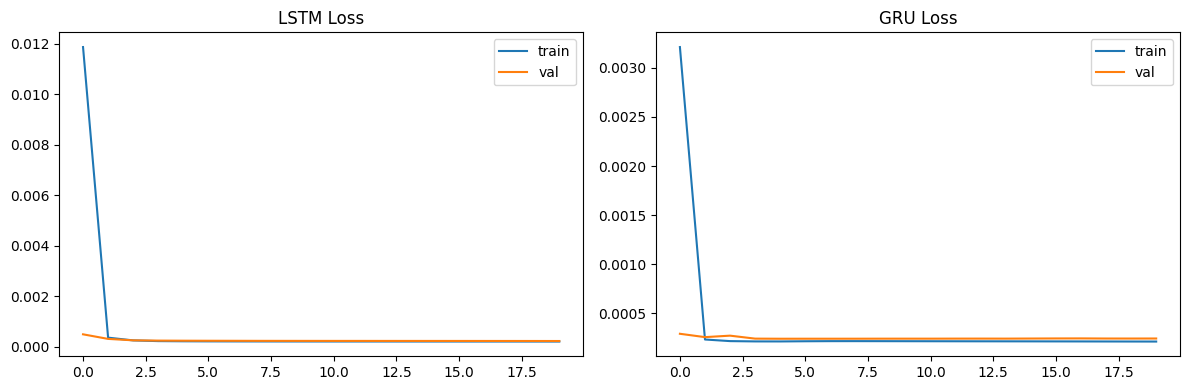

      fold         model      rmse       mae        r2
0  holdout   Persistence  0.935503  0.567398  0.992052
1  holdout    ARIMA_exog  0.892765  0.511567  0.992762
2  holdout  Holt-Winters  0.909107  0.515013  0.992495
3  holdout          LSTM  0.897190  0.503334  0.992677
4  holdout           GRU  0.850407  0.466532  0.993421


In [32]:
gru_pred_scaled = gru_model.predict(X_test_seq)
gru_pred = scaler_y.inverse_transform(gru_pred_scaled).flatten()

rmse, mae, r2 = eval_metrics(y_true_seq, gru_pred)
print(f"GRU — RMSE: {rmse:.4f}  MAE: {mae:.4f}  R2: {r2:.4f}")
results_df = pd.concat([results_df, pd.DataFrame([{"fold": "holdout", "model": "GRU", "rmse": rmse, "mae": mae, "r2": r2}])], ignore_index=True)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history.history["loss"], label="train"); axes[0].plot(history.history["val_loss"], label="val")
axes[0].set_title("LSTM Loss"); axes[0].legend()
axes[1].plot(gru_history.history["loss"], label="train"); axes[1].plot(gru_history.history["val_loss"], label="val")
axes[1].set_title("GRU Loss"); axes[1].legend()
plt.tight_layout()
plt.show()

print(results_df)

## Phase 4 — Rolling-Origin Cross-Validation + Hypothesis Testing

5 expanding-window folds, refitting every 1-minute-resolution model per fold (SARIMA excluded — different resolution, already caveated). This gives the fold-wise error distributions needed for genuine paired hypothesis tests (a single holdout split cannot support a paired t-test).

In [33]:
N = len(df)
n_blocks = 6
block_size = N // n_blocks
boundaries = [block_size * i for i in range(1, n_blocks + 1)]
boundaries[-1] = N

fold_splits = [(0, boundaries[i], boundaries[i+1]) for i in range(len(boundaries) - 1)]
for i, (s, tr, te) in enumerate(fold_splits, 1):
    print(f"Fold {i}: train 0-{tr} ({tr}) | test {tr}-{te} ({te-tr})")

Fold 1: train 0-6948 (6948) | test 6948-13896 (6948)
Fold 2: train 0-13896 (13896) | test 13896-20844 (6948)
Fold 3: train 0-20844 (20844) | test 20844-27792 (6948)
Fold 4: train 0-27792 (27792) | test 27792-34740 (6948)
Fold 5: train 0-34740 (34740) | test 34740-41691 (6951)


In [34]:
def fit_arima_exog_fold(train_slice, full_slice, train_len):
    model = SARIMAX(train_slice["Soil_Moisture"], exog=train_slice[exog_cols],
                     order=(0, 1, 1), enforce_stationarity=False, enforce_invertibility=False)
    fit = model.fit(disp=False)
    full_model = SARIMAX(full_slice["Soil_Moisture"], exog=full_slice[exog_cols],
                          order=(0, 1, 1), enforce_stationarity=False, enforce_invertibility=False)
    full_fit = full_model.filter(fit.params)
    pred = full_fit.get_prediction(start=train_len, end=len(full_slice) - 1, dynamic=False)

    return pred.predicted_mean.values[1:]

def fit_hw_fold(full_slice, train_len):
    _tf = ExponentialSmoothing(full_slice["Soil_Moisture"].iloc[:train_len],
                               trend="add", seasonal=None).fit()
    fit = ExponentialSmoothing(full_slice["Soil_Moisture"], trend="add", seasonal=None).fit(
        smoothing_level=_tf.params["smoothing_level"],
        smoothing_trend=_tf.params["smoothing_trend"], optimized=False)

    return fit.fittedvalues.iloc[train_len + 1:].values

def fit_lstm_gru_fold(train_slice, test_slice, cell_type="LSTM", epochs=10):
    sX, sy = MinMaxScaler(), MinMaxScaler()
    trX = sX.fit_transform(train_slice[feature_cols]); teX = sX.transform(test_slice[feature_cols])
    trY = sy.fit_transform(train_slice[[target_col]]); teY = sy.transform(test_slice[[target_col]])
    Xtr, ytr = create_sequences(trX, trY, SEQ_LENGTH)
    Xte, yte = create_sequences(teX, teY, SEQ_LENGTH)
    layer = layers.LSTM(32) if cell_type == "LSTM" else layers.GRU(32)
    model = models.Sequential([layers.Input(shape=(SEQ_LENGTH, len(feature_cols))), layer,
                                layers.Dense(16, activation="relu"), layers.Dense(1)])
    model.compile(optimizer="adam", loss="mse")
    model.fit(Xtr, ytr, epochs=epochs, batch_size=128, verbose=0)
    pred_scaled = model.predict(Xte, verbose=0)
    pred = sy.inverse_transform(pred_scaled).flatten()
    yt = sy.inverse_transform(yte).flatten()
    return yt, pred

print("Fold helper functions defined.")

Fold helper functions defined.


In [35]:
fold_results = []
for fold_num, (start, train_end, test_end) in enumerate(fold_splits, 1):
    print(f"=== Fold {fold_num} ===")
    train_slice = df.iloc[start:train_end].reset_index(drop=True)
    test_slice = df.iloc[train_end:test_end].reset_index(drop=True)
    full_slice = df.iloc[start:test_end].reset_index(drop=True)
    train_len = len(train_slice)
    yt = test_slice[target_col].values

    p_pred = test_slice["Soil_Moisture"].values
    r, m, r2_ = eval_metrics(yt, p_pred)
    fold_results.append({"fold": fold_num, "model": "Persistence", "rmse": r, "mae": m, "r2": r2_})

    a_pred = fit_arima_exog_fold(train_slice, full_slice, train_len)
    r, m, r2_ = eval_metrics(yt[:-1], a_pred)
    fold_results.append({"fold": fold_num, "model": "ARIMA_exog", "rmse": r, "mae": m, "r2": r2_})

    hw_pred = fit_hw_fold(full_slice, train_len)
    r, m, r2_ = eval_metrics(yt[:-1], hw_pred)
    fold_results.append({"fold": fold_num, "model": "Holt-Winters", "rmse": r, "mae": m, "r2": r2_})

    ytl, lstm_p = fit_lstm_gru_fold(train_slice, test_slice, "LSTM")
    r, m, r2_ = eval_metrics(ytl, lstm_p)
    fold_results.append({"fold": fold_num, "model": "LSTM", "rmse": r, "mae": m, "r2": r2_})

    ytg, gru_p = fit_lstm_gru_fold(train_slice, test_slice, "GRU")
    r, m, r2_ = eval_metrics(ytg, gru_p)
    fold_results.append({"fold": fold_num, "model": "GRU", "rmse": r, "mae": m, "r2": r2_})
    print(f"Fold {fold_num} done.")

cv_results_df = pd.DataFrame(fold_results)
print(cv_results_df.pivot(index="fold", columns="model", values="rmse").round(4))

=== Fold 1 ===
Fold 1 done.
=== Fold 2 ===
Fold 2 done.
=== Fold 3 ===
Fold 3 done.
=== Fold 4 ===
Fold 4 done.
=== Fold 5 ===
Fold 5 done.
model  ARIMA_exog     GRU  Holt-Winters    LSTM  Persistence
fold                                                        
1          0.9336  0.9464        0.9514  1.0959       0.9784
2          0.8002  0.9330        0.8108  1.2259       0.8543
3          0.9409  1.0789        0.9603  1.0441       0.9815
4          0.8107  0.7618        0.8232  0.8384       0.8623
5          0.9385  0.9314        0.9562  0.9306       0.9785


In [36]:
from scipy.stats import ttest_rel, wilcoxon

def compare_models(df_cv, model_a, model_b, metric="rmse"):
    a = df_cv[df_cv.model == model_a].sort_values("fold")[metric].values
    b = df_cv[df_cv.model == model_b].sort_values("fold")[metric].values
    t_stat, t_p = ttest_rel(a, b)
    try:
        w_stat, w_p = wilcoxon(a, b)
    except ValueError:
        w_stat, w_p = np.nan, np.nan
    print(f"{model_a} vs {model_b}: mean {a.mean():.4f} vs {b.mean():.4f} | t p={t_p:.4f} | Wilcoxon p={w_p:.4f}")

compare_models(cv_results_df, "ARIMA_exog", "LSTM")
compare_models(cv_results_df, "ARIMA_exog", "GRU")
compare_models(cv_results_df, "LSTM", "GRU")
compare_models(cv_results_df, "Persistence", "LSTM")
compare_models(cv_results_df, "Persistence", "ARIMA_exog")




ARIMA_exog vs LSTM: mean 0.8848 vs 1.0270 | t p=0.1378 | Wilcoxon p=0.1250
ARIMA_exog vs GRU: mean 0.8848 vs 0.9303 | t p=0.2974 | Wilcoxon p=0.4375
LSTM vs GRU: mean 1.0270 vs 0.9303 | t p=0.1740 | Wilcoxon p=0.3125
Persistence vs LSTM: mean 0.9310 vs 1.0270 | t p=0.2701 | Wilcoxon p=0.3125
Persistence vs ARIMA_exog: mean 0.9310 vs 0.8848 | t p=0.0001 | Wilcoxon p=0.0625
